# Data and Methods

## Conecting Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Importing packages and file loading

In [ ]:
# Importing Google Drive mount, and file loading

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

# Set a clean plotting theme
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

base_path = "/content/drive/MyDrive/DSPLC_GCW"

train_path = f"{base_path}/Hotel-A-train.csv"
valid_path = f"{base_path}/Hotel-A-validation.csv"
test_path = f"{base_path}/Hotel-A-test.csv"
dict_path = f"{base_path}/Hotel-A-data-dictionary.csv"

train_raw = pd.read_csv(train_path)
valid_raw = pd.read_csv(valid_path)
test_raw = pd.read_csv(test_path)
data_dict = pd.read_csv(dict_path)

print("Files loaded successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files loaded successfully.


## Raw dataset overview

In [ ]:
# Raw dataset overview

overview = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Rows": [train_raw.shape[0], valid_raw.shape[0], test_raw.shape[0]],
    "Columns": [train_raw.shape[1], valid_raw.shape[1], test_raw.shape[1]]
})

display(overview)

print("Train columns:")
display(pd.Series(train_raw.columns, name="Column_Name"))

print("Data dictionary preview:")
display(data_dict)

,Dataset,Rows,Columns
0,Train,27499,24
1,Validation,2749,24
2,Test,4318,23


Train columns:


,Column_Name
0,Reservation-id
1,Gender
2,Age
3,Ethnicity
4,Educational_Level
5,Income
6,Country_region
7,Hotel_Type
8,Expected_checkin
9,Expected_checkout


Data dictionary preview:


,Data Field,Description
0,Reservation-id,A unique booking id
1,Gender,Gender of the reservation person
2,Age,Age of the reservation person. Age is varying ...
3,Ethnicity,Ethnicity of the reservation person. This fiel...
4,Educational_Level,Educational level of the reservation person. T...
5,Income,Income of the reservation person. This field t...
6,Country_region,Country region of the reservation person. This...
7,Hotel_Type,Hotel type of the reservation; i.e City Hotels...
8,Expected_checkin,Expected check-in date
9,Expected_checkout,Expected checkout date


## Cleaning and feature-engineering

In [ ]:
# Reusable cleaning and feature-engineering

def clean_and_engineer(df, has_target=True):
    df = df.copy()

    # Parse dates
    for col in ["Expected_checkin", "Expected_checkout", "Booking_date"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], format="%m/%d/%Y", errors="coerce")

    # Standardise inconsistent text labels
    if "Reservation_Status" in df.columns:
        df["Reservation_Status"] = df["Reservation_Status"].replace({
            "Check-out": "Check-Out"
        })

    if "Ethnicity" in df.columns:
        df["Ethnicity"] = df["Ethnicity"].replace({
            "caucasian": "Caucasian"
        })

    # Derived fields
    df["lead_time"] = (df["Expected_checkin"] - df["Booking_date"]).dt.days
    df["stay_nights"] = (df["Expected_checkout"] - df["Expected_checkin"]).dt.days
    df["family_size"] = df["Adults"] + df["Children"] + df["Babies"]
    df["net_room_rate"] = df["Room_Rate"] * (1 - df["Discount_Rate"] / 100)
    df["potential_revenue"] = df["stay_nights"] * df["net_room_rate"]
    df["checkin_month"] = df["Expected_checkin"].dt.month

    # Age bands for EDA and revenue analysis
    df["age_band"] = pd.cut(
        df["Age"],
        bins=[0, 25, 35, 45, 55, 65, 120],
        labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"],
        include_lowest=True
    )

    # Convert invalid date logic into missing values
    df.loc[df["lead_time"] < 0, "lead_time"] = np.nan
    df.loc[df["stay_nights"] <= 0, "stay_nights"] = np.nan

    # Convert selected columns to categorical type
    categorical_cols = [
        "Gender", "Ethnicity", "Educational_Level", "Income", "Country_region",
        "Hotel_Type", "Meal_Type", "Visted_Previously", "Previous_Cancellations",
        "Deposit_type", "Booking_channel", "Required_Car_Parking", "Use_Promotion",
        "age_band"
    ]

    if has_target and "Reservation_Status" in df.columns:
        categorical_cols.append("Reservation_Status")

    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype("category")

    # Binary modelling target
    if has_target and "Reservation_Status" in df.columns:
        df["failed_booking"] = df["Reservation_Status"].isin(["Canceled", "No-Show"]).astype(int)

    return df

## Cleaning and check typed data

In [ ]:
# Clean datasets

train = clean_and_engineer(train_raw, has_target=True)
valid = clean_and_engineer(valid_raw, has_target=True)
test = clean_and_engineer(test_raw, has_target=False)

# Remove duplicate reservation IDs from training data
train = train.drop_duplicates(subset="Reservation-id", keep="first").copy()

print("Cleaned train shape:", train.shape)
print("Cleaned validation shape:", valid.shape)
print("Cleaned test shape:", test.shape)

dtype_summary = pd.DataFrame({
    "Column": train.columns,
    "Dtype": train.dtypes.astype(str).values
})

display(dtype_summary)

Cleaned train shape: (27495, 32)
Cleaned validation shape: (2749, 32)
Cleaned test shape: (4318, 30)


,Column,Dtype
0,Reservation-id,int64
1,Gender,category
2,Age,int64
3,Ethnicity,category
4,Educational_Level,category
5,Income,category
6,Country_region,category
7,Hotel_Type,category
8,Expected_checkin,datetime64[ns]
9,Expected_checkout,datetime64[ns]


## Data quality assessment

In [ ]:
# Data quality assessment

# Missing values
missing_table = train.isna().sum().reset_index()
missing_table.columns = ["Column", "Missing_Count"]
missing_table["Missing_%"] = (missing_table["Missing_Count"] / len(train) * 100).round(2)
missing_table = missing_table.sort_values("Missing_Count", ascending=False)

# Duplicate reservation IDs in raw training data
duplicate_id_count = train_raw["Reservation-id"].duplicated().sum()

# Inconsistent labels in raw data
raw_status_counts = train_raw["Reservation_Status"].value_counts(dropna=False).reset_index()
raw_status_counts.columns = ["Reservation_Status", "Count"]

# Invalid date logic check using raw data
temp_dates = train_raw.copy()
for col in ["Expected_checkin", "Expected_checkout", "Booking_date"]:
    temp_dates[col] = pd.to_datetime(temp_dates[col], format="%m/%d/%Y", errors="coerce")

temp_dates["raw_lead_time"] = (temp_dates["Expected_checkin"] - temp_dates["Booking_date"]).dt.days
temp_dates["raw_stay_nights"] = (temp_dates["Expected_checkout"] - temp_dates["Expected_checkin"]).dt.days

quality_summary = pd.DataFrame({
    "Issue": [
        "Duplicate Reservation-id values in raw train",
        "Negative lead_time values in raw train",
        "Non-positive stay_nights values in raw train",
        "Missing lead_time after cleaning"
    ],
    "Count": [
        duplicate_id_count,
        (temp_dates["raw_lead_time"] < 0).sum(),
        (temp_dates["raw_stay_nights"] <= 0).sum(),
        train["lead_time"].isna().sum()
    ]
})

print("Missing values table:")
display(missing_table)

print("Raw reservation-status labels:")
display(raw_status_counts)

print("Quality summary:")
display(quality_summary)

Missing values table:


,Column,Missing_Count,Missing_%
24,lead_time,506,1.84
0,Reservation-id,0,0.00
2,Age,0,0.00
1,Gender,0,0.00
4,Educational_Level,0,0.00
5,Income,0,0.00
6,Country_region,0,0.00
3,Ethnicity,0,0.00
8,Expected_checkin,0,0.00
9,Expected_checkout,0,0.00


Raw reservation-status labels:


,Reservation_Status,Count
0,Check-Out,19092
1,Canceled,4134
2,Check-out,2148
3,No-Show,2125


Quality summary:


,Issue,Count
0,Duplicate Reservation-id values in raw train,4
1,Negative lead_time values in raw train,506
2,Non-positive stay_nights values in raw train,0
3,Missing lead_time after cleaning,506


## Impausible values and outliers

In [ ]:
# Implausible-value checks and IQR-based outlier counts

range_checks = pd.DataFrame({
    "Variable": ["Age", "Adults", "Children", "Babies", "Discount_Rate", "Room_Rate", "lead_time", "stay_nights"],
    "Min": [
        train["Age"].min(),
        train["Adults"].min(),
        train["Children"].min(),
        train["Babies"].min(),
        train["Discount_Rate"].min(),
        train["Room_Rate"].min(),
        train["lead_time"].min(),
        train["stay_nights"].min()
    ],
    "Max": [
        train["Age"].max(),
        train["Adults"].max(),
        train["Children"].max(),
        train["Babies"].max(),
        train["Discount_Rate"].max(),
        train["Room_Rate"].max(),
        train["lead_time"].max(),
        train["stay_nights"].max()
    ]
})

def iqr_outlier_count(series):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((s < lower) | (s > upper)).sum()

outlier_table = pd.DataFrame({
    "Variable": ["Age", "Room_Rate", "Discount_Rate", "lead_time", "stay_nights"],
    "Outlier_Count": [
        iqr_outlier_count(train["Age"]),
        iqr_outlier_count(train["Room_Rate"]),
        iqr_outlier_count(train["Discount_Rate"]),
        iqr_outlier_count(train["lead_time"]),
        iqr_outlier_count(train["stay_nights"])
    ]
})

print("Range checks:")
display(range_checks)

print("IQR outlier counts:")
display(outlier_table)

Range checks:


,Variable,Min,Max
0,Age,18.0,70.0
1,Adults,1.0,5.0
2,Children,1.0,3.0
3,Babies,0.0,2.0
4,Discount_Rate,0.0,40.0
5,Room_Rate,100.0,250.0
6,lead_time,0.0,708.0
7,stay_nights,1.0,4.0


IQR outlier counts:


,Variable,Outlier_Count
0,Age,0
1,Room_Rate,0
2,Discount_Rate,0
3,lead_time,312
4,stay_nights,2295


## Numerical summary table

In [ ]:
# Numerical summary table

numeric_cols = [
    "Age", "Adults", "Children", "Babies", "Discount_Rate", "Room_Rate",
    "lead_time", "stay_nights", "family_size", "net_room_rate", "potential_revenue"
]

numerical_summary = train[numeric_cols].describe(percentiles=[0.25, 0.50, 0.75]).T
numerical_summary = numerical_summary[["min", "25%", "50%", "75%", "max", "std"]]
numerical_summary.columns = ["Min", "Q1", "Median", "Q3", "Max", "Std"]
numerical_summary = numerical_summary.round(2)

display(numerical_summary)

,Min,Q1,Median,Q3,Max,Std
Age,18.0,31.0,44.0,57.00,70.0,15.30
Adults,1.0,2.0,2.0,3.00,5.0,1.18
Children,1.0,1.0,2.0,2.00,3.0,0.72
Babies,0.0,0.0,0.0,1.00,2.0,0.57
Discount_Rate,0.0,5.0,10.0,20.00,40.0,11.21
Room_Rate,100.0,137.0,175.0,214.00,250.0,43.88
lead_time,0.0,48.0,103.0,167.00,708.0,77.26
stay_nights,1.0,1.0,2.0,2.00,4.0,0.99
family_size,2.0,3.0,4.0,5.00,10.0,1.49
net_room_rate,60.0,117.6,150.3,186.75,250.0,43.47


## Categorial summary table


In [ ]:
# Categorical summary table

categorical_cols = [
    "Gender", "Ethnicity", "Educational_Level", "Income", "Country_region",
    "Hotel_Type", "Meal_Type", "Visted_Previously", "Previous_Cancellations",
    "Deposit_type", "Booking_channel", "Required_Car_Parking",
    "Reservation_Status", "Use_Promotion"
]

cat_tables = []

for col in categorical_cols:
    temp = train[col].value_counts(dropna=False).reset_index()
    temp.columns = ["Category", "Count"]
    temp["Proportion_%"] = (temp["Count"] / len(train) * 100).round(2)
    temp.insert(0, "Variable", col)
    cat_tables.append(temp)

categorical_summary = pd.concat(cat_tables, ignore_index=True)
display(categorical_summary)

,Variable,Category,Count,Proportion_%
0,Gender,F,13797,50.18
1,Gender,M,13698,49.82
2,Ethnicity,African American,6963,25.32
3,Ethnicity,Caucasian,6889,25.06
4,Ethnicity,Asian American,6838,24.87
5,Ethnicity,Latino,6805,24.75
6,Educational_Level,College,11050,40.19
7,Educational_Level,High-School,5521,20.08
8,Educational_Level,Mid-School,5480,19.93
9,Educational_Level,Grad,5444,19.80


## Univariate

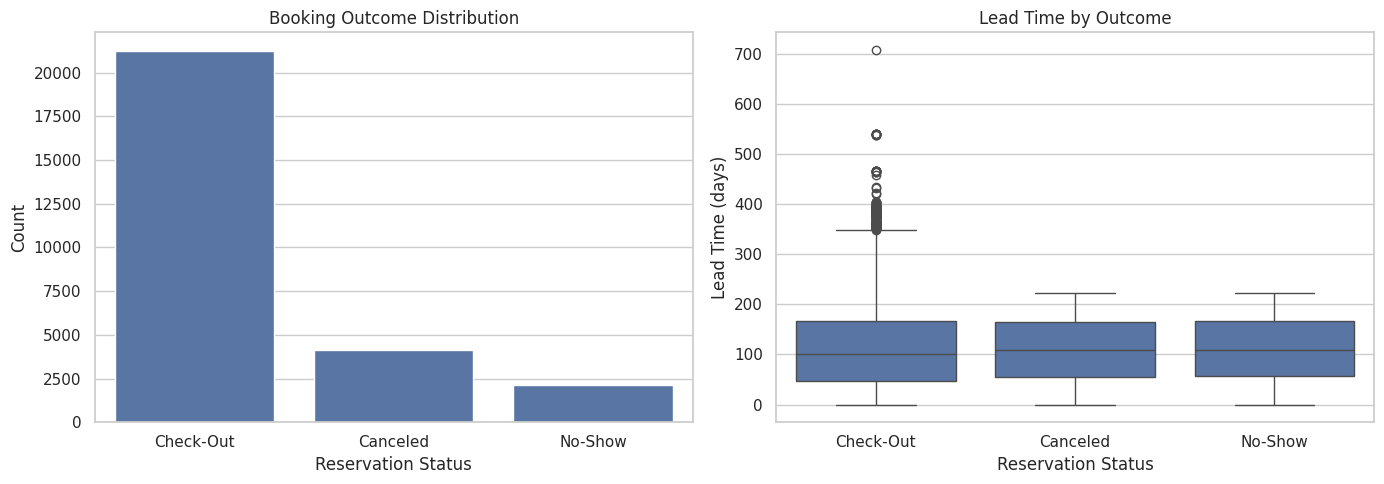

In [ ]:
# Univariate EDA

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Booking outcome distribution
order = ["Check-Out", "Canceled", "No-Show"]
sns.countplot(data=train, x="Reservation_Status", order=order, ax=axes[0])
axes[0].set_title("Booking Outcome Distribution")
axes[0].set_xlabel("Reservation Status")
axes[0].set_ylabel("Count")

# Lead time by outcome
sns.boxplot(data=train, x="Reservation_Status", y="lead_time", order=order, ax=axes[1])
axes[1].set_title("Lead Time by Outcome")
axes[1].set_xlabel("Reservation Status")
axes[1].set_ylabel("Lead Time (days)")

plt.tight_layout()
plt.show()

## Bivariate EDA: hotel type, booking channel, and deposit type

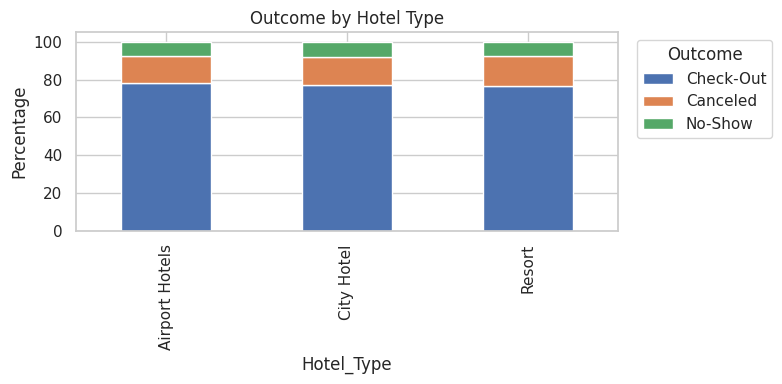

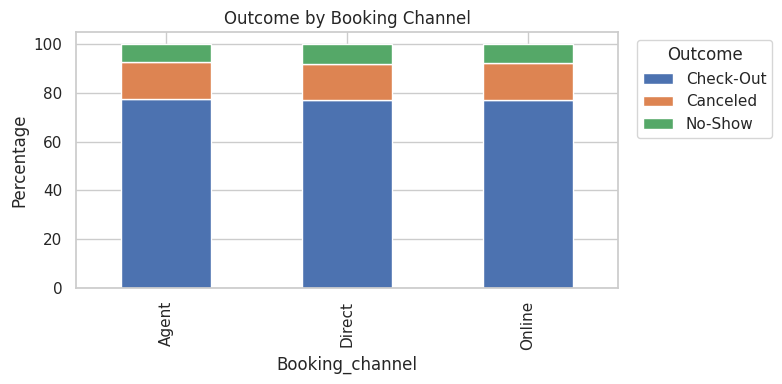

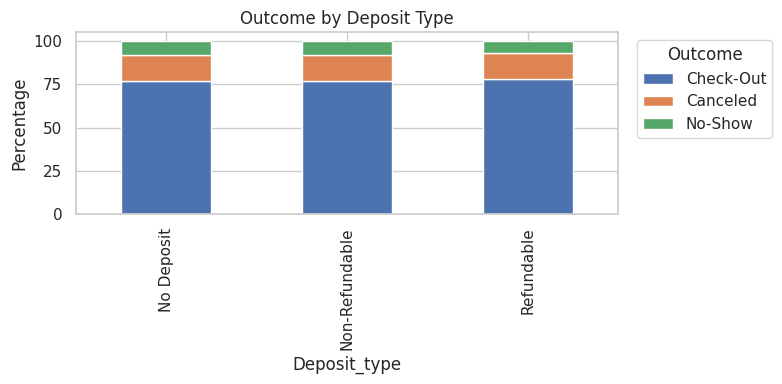

In [ ]:
# Bivariate EDA for hotel type, booking channel, and deposit type

def plot_outcome_share(df, feature, title):
    temp = pd.crosstab(df[feature], df["Reservation_Status"], normalize="index") * 100
    temp = temp[["Check-Out", "Canceled", "No-Show"]]
    temp.plot(kind="bar", stacked=True, figsize=(8, 4))
    plt.title(title)
    plt.ylabel("Percentage")
    plt.xlabel(feature)
    plt.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_outcome_share(train, "Hotel_Type", "Outcome by Hotel Type")
plot_outcome_share(train, "Booking_channel", "Outcome by Booking Channel")
plot_outcome_share(train, "Deposit_type", "Outcome by Deposit Type")

## Bivariate EDA: age band, region, pricing

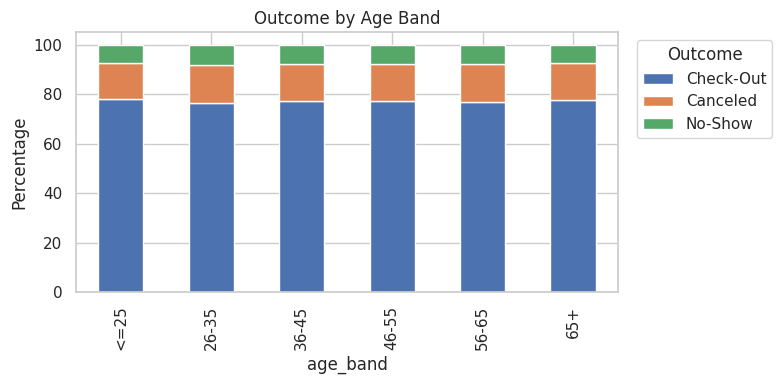

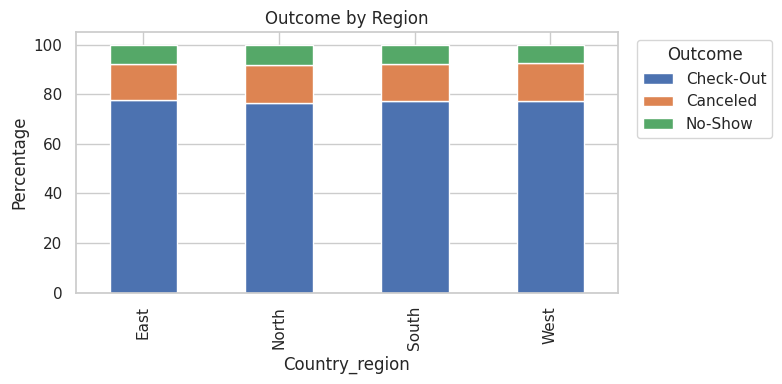

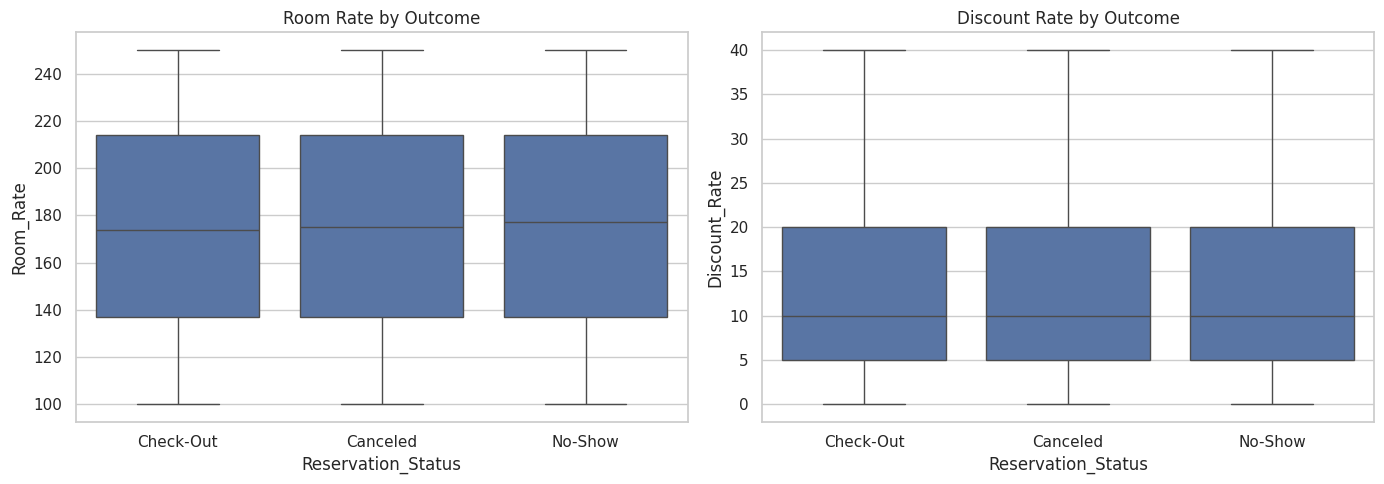

In [ ]:
# Bivariate EDA for age band, region, room rate, and discount rate

plot_outcome_share(train, "age_band", "Outcome by Age Band")
plot_outcome_share(train, "Country_region", "Outcome by Region")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=train, x="Reservation_Status", y="Room_Rate",
            order=["Check-Out", "Canceled", "No-Show"], ax=axes[0])
axes[0].set_title("Room Rate by Outcome")

sns.boxplot(data=train, x="Reservation_Status", y="Discount_Rate",
            order=["Check-Out", "Canceled", "No-Show"], ax=axes[1])
axes[1].set_title("Discount Rate by Outcome")

plt.tight_layout()
plt.show()

## Multivariate EDA: monthly trend and coorelation heatmap

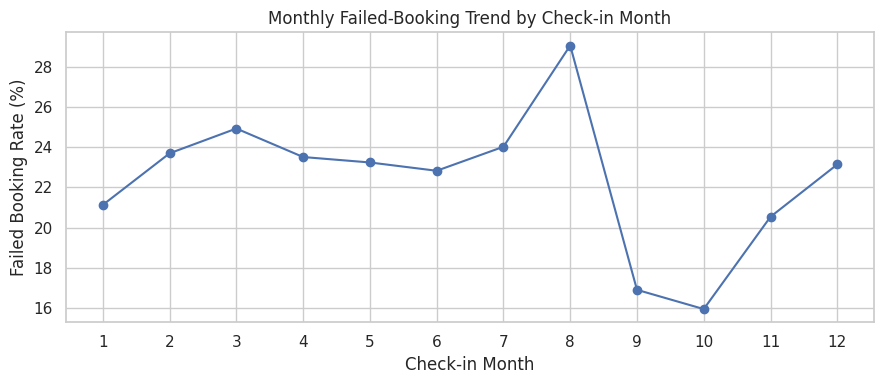

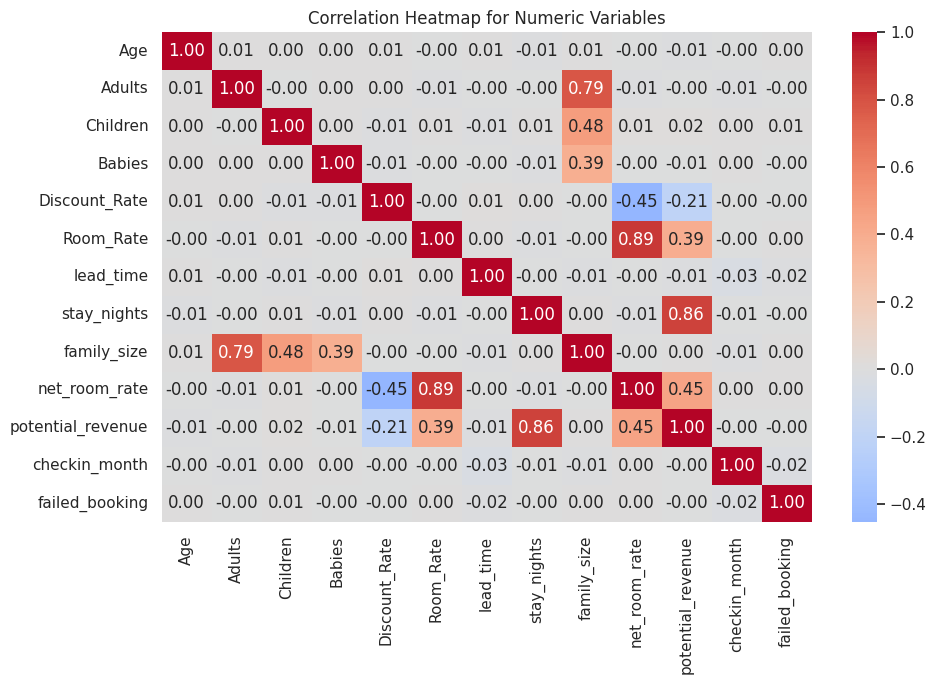

In [ ]:
# Multivariate EDA

# Monthly failed-booking trend
monthly_failed_rate = train.groupby("checkin_month")["failed_booking"].mean() * 100

plt.figure(figsize=(9, 4))
monthly_failed_rate.plot(marker="o")
plt.title("Monthly Failed-Booking Trend by Check-in Month")
plt.xlabel("Check-in Month")
plt.ylabel("Failed Booking Rate (%)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

# Correlation heatmap
heatmap_cols = [
    "Age", "Adults", "Children", "Babies", "Discount_Rate", "Room_Rate",
    "lead_time", "stay_nights", "family_size", "net_room_rate",
    "potential_revenue", "checkin_month", "failed_booking"
]

corr_matrix = train[heatmap_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap for Numeric Variables")
plt.tight_layout()
plt.show()

## Revenue loss

In [ ]:
# Revenue-loss analysis

# Required and supplementary metrics
cancellation_loss = train.loc[train["Reservation_Status"] == "Canceled", "potential_revenue"].sum()
no_show_loss = train.loc[train["Reservation_Status"] == "No-Show", "potential_revenue"].sum()
failed_booking_loss = train.loc[train["failed_booking"] == 1, "potential_revenue"].sum()
total_potential_revenue = train["potential_revenue"].sum()

revenue_summary = pd.DataFrame({
    "Metric": ["Cancellation loss", "No-show loss", "Failed-booking loss", "Total potential revenue"],
    "Value": [cancellation_loss, no_show_loss, failed_booking_loss, total_potential_revenue]
}).round(2)

revenue_summary["Share_of_Total_%"] = (
    revenue_summary["Value"] / total_potential_revenue * 100
).round(2)

display(revenue_summary)


loss_by_age = (
    train.loc[train["failed_booking"] == 1]
    .groupby("age_band", observed=False)["potential_revenue"]
    .sum()
    .reset_index()
    .rename(columns={"potential_revenue": "Revenue_Loss"})
    .round(2)
)

loss_by_region = (
    train.loc[train["failed_booking"] == 1]
    .groupby("Country_region")["potential_revenue"]
    .sum()
    .reset_index()
    .rename(columns={"potential_revenue": "Revenue_Loss"})
    .sort_values("Revenue_Loss", ascending=False)
    .round(2)
)

loss_by_hotel = (
    train.loc[train["failed_booking"] == 1]
    .groupby("Hotel_Type")["potential_revenue"]
    .sum()
    .reset_index()
    .rename(columns={"potential_revenue": "Revenue_Loss"})
    .sort_values("Revenue_Loss", ascending=False)
    .round(2)
)

print("Revenue loss by age band")
display(loss_by_age)

print("Revenue loss by region")
display(loss_by_region)

print("Revenue loss by hotel type")
display(loss_by_hotel)

,Metric,Value,Share_of_Total_%
0,Cancellation loss,1160410.45,15.02
1,No-show loss,594017.75,7.69
2,Failed-booking loss,1754428.20,22.71
3,Total potential revenue,7724462.80,100.00


Revenue loss by age band


/tmp/ipykernel_10304/563304262.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Country_region")["potential_revenue"]
/tmp/ipykernel_10304/563304262.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Hotel_Type")["potential_revenue"]


,age_band,Revenue_Loss
0,<=25,256960.30
1,26-35,347017.70
2,36-45,332602.20
3,46-55,324097.45
4,56-65,334400.70
5,65+,159349.85


Revenue loss by region


,Country_region,Revenue_Loss
2,South,692184.95
1,North,368177.75
0,East,349926.15
3,West,344139.35


Revenue loss by hotel type


,Hotel_Type,Revenue_Loss
2,Resort,596404.05
1,City Hotel,581986.45
0,Airport Hotels,576037.70


## Modelling dataset preparation

In [ ]:
# Modelling dataset preparation

# Using train for fitting, validation for model selection, test for final scoring only

feature_cols = [
    "Gender", "Age", "Ethnicity", "Educational_Level", "Income", "Country_region",
    "Hotel_Type", "Adults", "Children", "Babies", "Meal_Type",
    "Visted_Previously", "Previous_Cancellations", "Deposit_type",
    "Booking_channel", "Required_Car_Parking", "Use_Promotion",
    "Discount_Rate", "Room_Rate", "lead_time", "stay_nights",
    "family_size", "checkin_month"
]

# No leakage fields:
# - Reservation-id
# - Reservation_Status
# - raw date columns
# - revenue fields such as net_room_rate and potential_revenue

X_train = train[feature_cols]
y_train = train["failed_booking"]

X_valid = valid[feature_cols]
y_valid = valid["failed_booking"]

X_test = test[feature_cols]

categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = [col for col in feature_cols if col not in categorical_features]

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

Categorical features: ['Gender', 'Ethnicity', 'Educational_Level', 'Income', 'Country_region', 'Hotel_Type', 'Meal_Type', 'Visted_Previously', 'Previous_Cancellations', 'Deposit_type', 'Booking_channel', 'Required_Car_Parking', 'Use_Promotion']
Numeric features: ['Age', 'Adults', 'Children', 'Babies', 'Discount_Rate', 'Room_Rate', 'lead_time', 'stay_nights', 'family_size', 'checkin_month']


## Preprocessing pipeline and model training

In [ ]:
# Preprocessing pipeline and model comparison

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# Reproducible preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    )
}

results = []
fitted_models = {}
conf_matrices = {}

for model_name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_valid)
    y_prob = pipe.predict_proba(X_valid)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_valid, y_pred),
        "Precision": precision_score(y_valid, y_pred),
        "Recall": recall_score(y_valid, y_pred),
        "F1": f1_score(y_valid, y_pred),
        "ROC_AUC": roc_auc_score(y_valid, y_prob)
    })

    fitted_models[model_name] = pipe
    conf_matrices[model_name] = confusion_matrix(y_valid, y_pred)

results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Decision Tree,0.5038,0.4290,0.597,0.4993,0.5224
1,Random Forest,0.4893,0.4209,0.619,0.5011,0.5217
2,Logistic Regression,0.5038,0.4345,0.655,0.5224,0.5182


## Confusion matrices

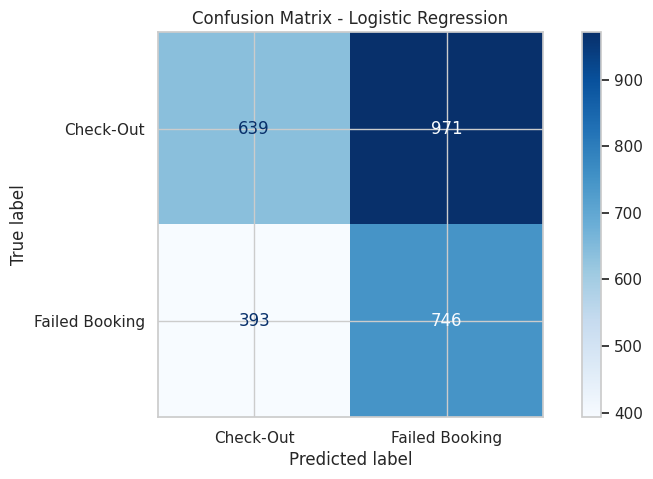

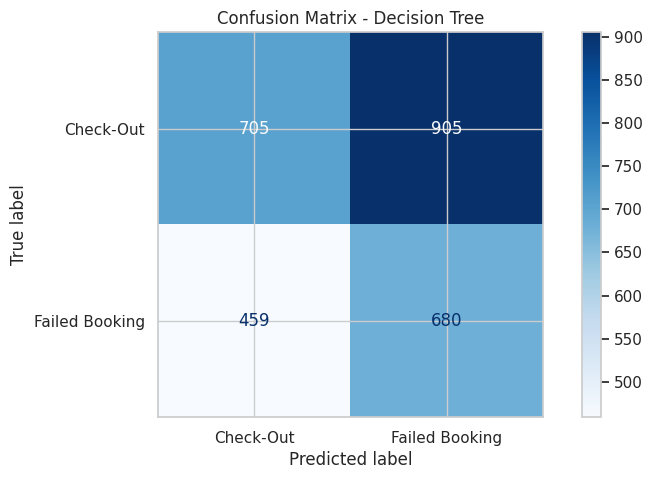

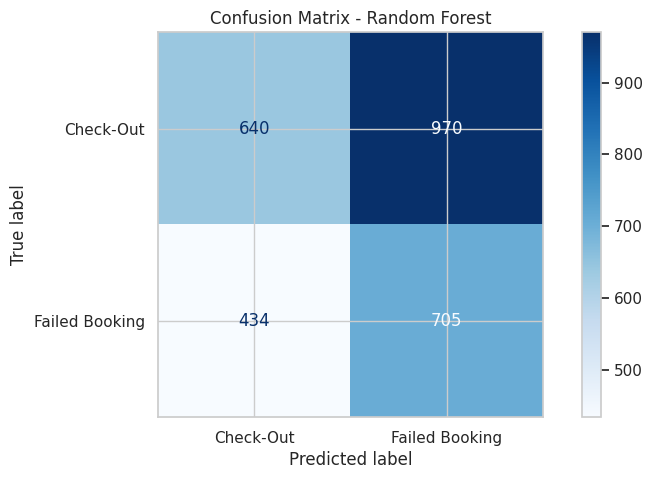

In [ ]:
# Confusion matrices for the validation set

from sklearn.metrics import ConfusionMatrixDisplay

for model_name, cm in conf_matrices.items():
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Check-Out", "Failed Booking"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

## Final scoring on the test set

In [ ]:
# Final scoring on the test set using the best validation model

# Choose the best model based on validation ROC_AUC or F1
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

print("Selected best model:", best_model_name)

# Refit on train + validation before final test scoring
combined = pd.concat([train, valid], ignore_index=True)

X_combined = combined[feature_cols]
y_combined = combined["failed_booking"]

best_model.fit(X_combined, y_combined)

# Final scoring only (test has no target)
test_scored = test.copy()
test_scored["failed_booking_probability"] = best_model.predict_proba(X_test)[:, 1]
test_scored["predicted_failed_booking"] = (test_scored["failed_booking_probability"] >= 0.50).astype(int)

display(test_scored[["Reservation-id", "failed_booking_probability", "predicted_failed_booking"]].head())

# Save for submission / appendix
test_predictions = test_scored[["Reservation-id", "failed_booking_probability", "predicted_failed_booking"]]
test_predictions.to_csv(f"{base_path}/Hotel_A_test_predictions.csv", index=False)

print("Test predictions file saved.")

Selected best model: Decision Tree


,Reservation-id,failed_booking_probability,predicted_failed_booking
0,62931593,0.516735,1
1,70586099,0.655694,1
2,4230648,0.314062,0
3,25192322,0.717422,1
4,80931528,0.314062,0


Test predictions file saved.
